In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')                          # auth popup, once per session
RESULTS_DIR = '/content/drive/MyDrive/thesis_results'  # change name if you like
os.makedirs(RESULTS_DIR, exist_ok=True)
os.chdir(RESULTS_DIR)                                   # all relative saves now land here
print('Saving to:', os.getcwd())

Mounted at /content/drive
Saving to: /content/drive/MyDrive/thesis_results


In [ ]:
# Imports

## Core libraries
import numpy as np
import matplotlib.pyplot as plt

## TensorFlow / Keras
import tensorflow as tf
import keras
from keras import ops, layers
from keras.callbacks import Callback
from keras.models import Sequential, Model
from keras.layers import Input, Conv2D, Dense


In [ ]:
# Setting seeds

np.random.seed(1999)
tf.random.set_seed(1999)


In [ ]:
# Loading the dataset

(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

## Feature scaling (mapping pixel values to [0,1])
'''
This is used as neural network training via gradient descent is sensitive to the
scale of inputs (through activations a = Wx + b). This causes gradients to vanish
and makes the loss landscape poorly conditioned.
'''
x_train_full = x_train_full / 255.0
x_test = x_test / 255.0

''' Recalling our y values are our categories '''
y_train_full = keras.utils.to_categorical(y_train_full, 10)
y_test = keras.utils.to_categorical(y_test, 10)

## Setting up our validation dataset
n_val = int(0.2 * len(x_train_full))
perm = np.random.permutation(len(x_train_full))
val_idx, train_idx = perm[:n_val], perm[n_val:]
x_val, y_val = x_train_full[val_idx], y_train_full[val_idx]
x_train, y_train = x_train_full[train_idx], y_train_full[train_idx]

## Check
print(f"train: {x_train.shape} val: {x_val.shape} test: {x_test.shape}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
train: (40000, 32, 32, 3) val: (10000, 32, 32, 3) test: (10000, 32, 32, 3)


In [ ]:
# Augmenting the dataset
'''
This involves creating new training examples by applying label preserving
transformations to existing examples e.g. flips, crops, scaling, colour jitter,
adding noise, ...
'''

'''
Applying three transformations in sequence, we pad the image with black 0s,
then randomly crop the newly padded image (so the model learns that a shifted
horse picture is still a horse), and then randomly mirroring the image from left
to right.
'''
augment = keras.Sequential([layers.ZeroPadding2D(padding=4),
                            layers.RandomCrop(32, 32),
                            layers.RandomFlip("horizontal")])

batch_size = 128

'''
This builds the full training data pipeline, where:
- The from_tensor_slices((x_train, y_train)) wraps the numpy arrays into a
  tf.data.Dataset that has image label pairs one at a time.
- For .shuffle(len(x_train)) - this shifts the entire dataset after each epoch.
- For .map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
  this applies the augmentation pipeline to each batch of images whilst leaving
  labels untouched. The training=True is important because RandomCrop and
  RandomFlip only apply their transformations during training. The
  num_parallel_calls=tf.data.AUTOTUNE lets TensorFlow decide how many batches to
  augment in parallel across CPU threads.
'''
train_ds = (tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(len(x_train)).batch(batch_size).map(lambda x, y: (augment(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE))

### Recalling that there is no augmentation for validation and test datasets
val_ds  = (tf.data.Dataset.from_tensor_slices((x_val,  y_val ))
           .batch(batch_size).prefetch(tf.data.AUTOTUNE))
test_ds = (tf.data.Dataset.from_tensor_slices((x_test, y_test))
           .batch(batch_size).prefetch(tf.data.AUTOTUNE))


In [ ]:
# Residual block (no dropout)
'''
Here is the specification requirements for a single residual block (the repeating
unit in ResNet-20). Instead of learning the mapping between the input and the
output, we instead learn the difference between the input and the desired output
(the residual).

In this, the shortcut path passes the input unchanged (albeit with a channel
count change to match shapes at times). These two paths are added together for
a final ReLU.
'''

### We recall that a convolution slides a small window (a kernel/filter) across our grid.
### A single kernel produces one output grid (one channel). One kernel might learn to detect vertical edges, another colour gradients, and so on.
### We thus use 16 kernels simultaneously to produce an output with 16 channels.

class ResidualBlock(keras.layers.Layer):

    '''
    The init method constructs everything which doesn't fit into the other categories.
    In this, we construct the two convolutional layers and the ReLU activation.
    Everything here is created once and reused when the block processes an input.
    Projection is handled separately, as the input's channel count changes.
    '''
    def __init__(self, filters, stride=1, **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.stride = stride

        ### The same padding here adds just enough padding at each convolution step so the output spatial dimensions match the input.
        ### The kernel initialiser establishes starting weights for the kernels such that they are not all zero (each kernel learns the same thing), too large (where activations explode), or too small (vanishing to zero).
        self.conv1 = layers.Conv2D(filters, 3, strides=stride, padding="same",
                                   kernel_regularizer=keras.regularizers.L2(1e-4),
                                   kernel_initializer="he_normal")

        ### Batch normalisation ensures each channel has a mean of 0 and a variance of 1.
        ### This is necessary for faster and more stable training as the weights update during training, causing our outputs to shift considerably (and calibrated to the old weights).
        ### The purpose of batch normalisation is to ensure a stable range of outputs.
        self.bn1 = layers.BatchNormalization()
        self.conv2 = layers.Conv2D(filters, 3, padding="same",
                                   kernel_regularizer=keras.regularizers.L2(1e-4),
                                   kernel_initializer="he_normal")
        self.bn2 = layers.BatchNormalization()
        self.relu = layers.Activation("relu")

    ### Going deeper into the network, we want to detect increasingly abstract features.
    ### We therefore downsample (have a bigger stride) as we detect combinations.
    ### We compensate for that by increasing the number of channels.

    '''
    The build method handles the projection shortcut (and handles shape-matching if needed).
    '''
    def build(self, input_shape):
        in_channels = input_shape[-1]

        if self.stride != 1 or in_channels != self.filters:
            self.proj = layers.Conv2D(self.filters, 1, strides=self.stride, padding="valid",
                                      kernel_regularizer=keras.regularizers.L2(1e-4),
                                      kernel_initializer="he_normal")
            self.bn_proj = layers.BatchNormalization()
        else:
            self.proj = None

        super().build(input_shape)

    '''
    The call method runs the actual forward pass of the model organising the
    split into the main convolutional path and the shortcut path, then summing
    them and applying ReLU.
    '''
    def call(self, x):
        if self.proj is not None:
            shortcut = self.bn_proj(self.proj(x))
        else:
            shortcut = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        return self.relu(out + shortcut)

    '''
    The get_config method enables serialisation so Keras can save/load the model.
    '''
    def get_config(self):
        config = super().get_config()
        config.update({"filters": self.filters,
                       "stride": self.stride})
        return config


In [ ]:
# build_resnet20 — deterministic / SWAG variant (no dropout)
'''
The full architecture follows the ResNet-20 spec of He et al. (2016) for CIFAR:
an initial conv, three stages of three residual blocks at filter widths
{16, 32, 64}, with the first block of stages 2 and 3 using stride 2 to halve
spatial resolution while doubling channels.
'''
def build_resnet20():
    inputs = keras.Input(shape=(32, 32, 3))

    x = layers.Conv2D(16, 3, padding="same",
                      kernel_regularizer=keras.regularizers.L2(1e-4),
                      kernel_initializer="he_normal")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    for _ in range(3):
        x = ResidualBlock(16)(x)

    x = ResidualBlock(32, stride=2)(x)
    for _ in range(2):
        x = ResidualBlock(32)(x)

    x = ResidualBlock(64, stride=2)(x)
    for _ in range(2):
        x = ResidualBlock(64)(x)

    ### Global average pooling takes the block's output and feeds it into a final dense layer for classification.
    ### It takes the 64 feature maps (each of which is an 8x8 grid) and averages each grid into a single number. The output is a flat vector of length 64, that feeds into the final dense layer for classification.
    ### This is therefore translation invariant (if a feature shifts position in the 8x8 grid, the average barely changes), so classification is stable.
    x = layers.GlobalAveragePooling2D()(x)

    outputs = layers.Dense(10, kernel_initializer="he_normal")(x)

    return keras.Model(inputs, outputs)


In [ ]:
# Building deterministic model

model = build_resnet20()


In [ ]:
# Training deterministic model

'''
Step-wise learning-rate schedule: drop by 10x at epochs 100 and 150.
This is the standard CIFAR ResNet schedule from He et al. (2016) and matches
what we'll re-use for MC Dropout (so the three baselines differ only in the
stochasticity mechanism, not in the optimisation recipe).
'''
def lr_schedule(epoch, lr):
    if epoch in (100, 150):
        return lr * 0.1
    return lr


In [ ]:
# Compiling

### This doesn't run any training or touch any data, but it configures the optimiser (how weights are updated), the loss function, and optionally any metrics we want to track.
model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.1, momentum=0.9),
              loss=keras.losses.CategoricalCrossentropy(from_logits=True),
              metrics=["categorical_accuracy"])


In [ ]:
# Callbacks for checkpoints

callbacks = [keras.callbacks.ModelCheckpoint("resnet20_best.weights.h5",
                                             monitor="val_loss",
                                             save_best_only=True,
                                             save_weights_only=True),
             keras.callbacks.LearningRateScheduler(lr_schedule, verbose=1)] # calls lr_schedule function each epoch to reduce learning rate


In [ ]:
# Training

history = model.fit(train_ds,
                    epochs=200,
                    validation_data=val_ds,
                    callbacks=callbacks)


model.load_weights("resnet20_best.weights.h5") # Loading best checkpoints

# Final evaluation on test set
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\nTest loss: {test_loss:.4f}  Test accuracy: {test_acc:.4f}")



Epoch 1: LearningRateScheduler setting learning rate to 0.10000000149011612.
Epoch 1/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 49ms/step - categorical_accuracy: 0.3947 - loss: 1.8025 - val_categorical_accuracy: 0.3452 - val_loss: 2.1261 - learning_rate: 0.1000

Epoch 2: LearningRateScheduler setting learning rate to 0.10000000149011612.
Epoch 2/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - categorical_accuracy: 0.5610 - loss: 1.3743 - val_categorical_accuracy: 0.5479 - val_loss: 1.4808 - learning_rate: 0.1000

Epoch 3: LearningRateScheduler setting learning rate to 0.10000000149011612.
Epoch 3/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - categorical_accuracy: 0.6409 - loss: 1.1648 - val_categorical_accuracy: 0.6200 - val_loss: 1.2855 - learning_rate: 0.1000

Epoch 4: LearningRateScheduler setting learning rate to 0.10000000149011612.
Epoch 4/200
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - categorical_accuracy: 0.6976 - loss: 1.0212 - val_categorical_accuracy: 0.4256 - val_loss: 2.6310

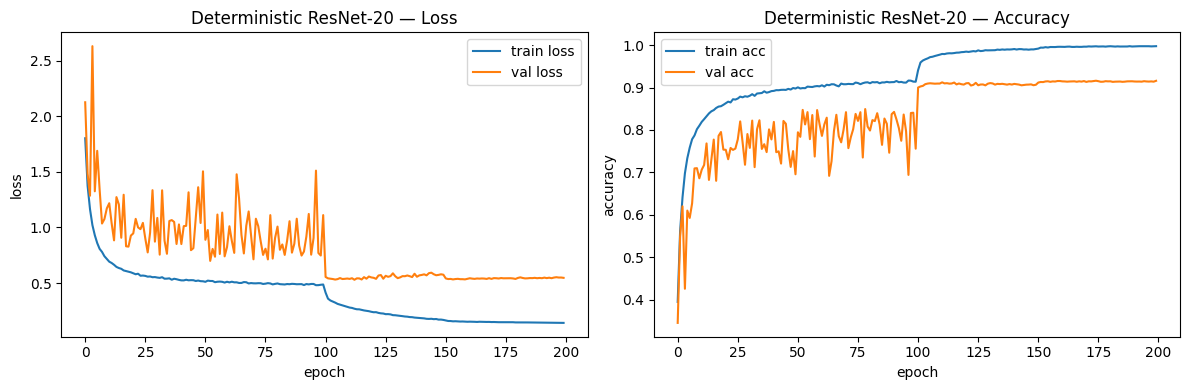

In [ ]:
# Plotting training curves

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

## Plot 1
ax1.plot(history.history["loss"], label="train loss")
ax1.plot(history.history["val_loss"], label="val loss")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss")
ax1.set_title("Deterministic ResNet-20 — Loss"); ax1.legend()

## Plot 2
ax2.plot(history.history["categorical_accuracy"], label="train acc")
ax2.plot(history.history["val_categorical_accuracy"], label="val acc")
ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy")
ax2.set_title("Deterministic ResNet-20 — Accuracy"); ax2.legend()
plt.tight_layout(); plt.show()


In [ ]:
# Loading SVHN as the out-of-distribution reference set
'''
Per the proposal §3.5, SVHN (street view of house numbers) is used as the
OOD test set. SVHN images are 32x32 colour photos like CIFAR-10, but of
digits, so a CIFAR-10 trained model should ideally report higher predictive
entropy on SVHN inputs than on its in-distribution CIFAR-10 test images.

The whole SVHN test split is ~26k examples; we load it via
tensorflow_datasets and rescale to [0, 1] to match CIFAR-10 preprocessing.
'''
import tensorflow_datasets as tfds

svhn = tfds.load("svhn_cropped", split="test", as_supervised=True)
svhn_images = []
for img, _ in svhn:
    svhn_images.append(img.numpy())
x_svhn = np.stack(svhn_images).astype("float32") / 255.0

print(f"SVHN OOD set: {x_svhn.shape}")


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/svhn_cropped/incomplete.FBV8ZC_3.1.0/svhn_cropped-train.tfrecord-[0-9][0-9…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/svhn_cropped/incomplete.FBV8ZC_3.1.0/svhn_cropped-test.tfrecord-[0-9][0-9]…

Generating extra examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/svhn_cropped/incomplete.FBV8ZC_3.1.0/svhn_cropped-extra.tfrecord-[0-9][0-9…

Dataset svhn_cropped downloaded and prepared to /root/tensorflow_datasets/svhn_cropped/3.1.0. Subsequent calls will reuse this data.
SVHN OOD set: (26032, 32, 32, 3)


In [ ]:
# Generating predictions for the evaluation file
'''
This is the only output the downstream evaluation notebook needs from this
file. We produce softmax probabilities on:
  - the CIFAR-10 test set (in-distribution),
  - the SVHN test set (out-of-distribution),
and stash the true labels and the predicted classes alongside.

The deterministic model has a single forward pass per input, so there are no
MC samples to save - the eval file will treat probs_test as a degenerate S=1
predictive distribution.
'''

## In-distribution: CIFAR-10 test set
logits_test = model.predict(test_ds)                        # (10000, 10)
probs_test  = tf.nn.softmax(logits_test, axis=-1).numpy()
preds_test  = np.argmax(probs_test, axis=1)
labels_test = np.argmax(y_test, axis=1)

print(f"Test accuracy: {(preds_test == labels_test).mean():.4f}")

## Out-of-distribution: SVHN test set
logits_svhn = model.predict(x_svhn, batch_size=128)
probs_svhn  = tf.nn.softmax(logits_svhn, axis=-1).numpy()

print(f"probs_test:  {probs_test.shape}")
print(f"probs_svhn:  {probs_svhn.shape}")


79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step
Test accuracy: 0.9111
204/204 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
probs_test:  (10000, 10)
probs_svhn:  (26032, 10)


In [ ]:
# Saving raw outputs for the evaluation file
'''
Save format (shared across all benchmarks). The evaluation notebook will
load these by filename and produce ECE, reliability diagrams, OOD AUROC,
risk-coverage and (for the BNN benchmarks) the epistemic / aleatoric
decomposition.

Keys:
  model_name     - human-readable string identifier
  probs_test     - (N_test, 10)  mean predictive distribution on CIFAR-10 test
  labels_test    - (N_test,)     true labels (integer 0-9)
  preds_test     - (N_test,)     argmax of probs_test
  probs_svhn     - (N_svhn, 10)  mean predictive distribution on SVHN OOD
  all_probs_test - (S, N_test, 10) per-sample probs (None for deterministic)
  all_probs_svhn - (S, N_svhn, 10) per-sample probs (None for deterministic)
'''
np.savez("deterministic_results.npz",
         model_name="deterministic",
         probs_test=probs_test,
         labels_test=labels_test,
         preds_test=preds_test,
         probs_svhn=probs_svhn,
         all_probs_test=probs_test[None, :, :],   # treat as S=1 for uniform eval API
         all_probs_svhn=probs_svhn[None, :, :])

print("Saved deterministic_results.npz")


Saved deterministic_results.npz
